In [1]:
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
print(tf.__version__)

2.21.0


In [14]:
(X_train,Y_train),(X_test,Y_test) = tf.keras.datasets.mnist.load_data()

In [15]:
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(60000, 28, 28) (10000, 28, 28) (60000,) (10000,)


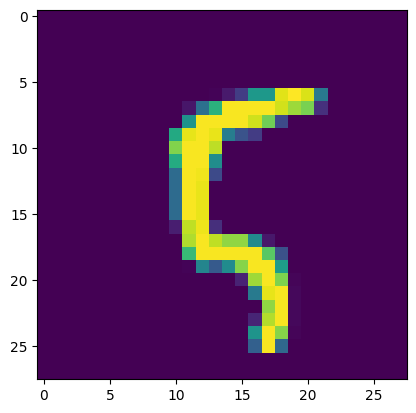

In [5]:
plt.imshow(X_train[100])

In [6]:
Y_train[100]

np.uint8(5)

In [16]:
X_train = X_train.reshape((-1, 28, 28, 1)).astype('float32') / 255
X_test = X_test.reshape((-1, 28, 28, 1)).astype('float32') / 255

In [17]:
X_train.shape,X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [30]:
#valid - default - zero padding  , (1,1) - default stride 

#1d 
#output = (input+(2*padding)-kernel_size)/stride + 1  #same can be extended for each h,w for 2D

def find_output_shape(input_shape=(28,28),padding=(0,0),kernel_size=(3,3),stride = (1,1)):
    output = [0,0]
    output[0] = (input_shape[0]+(2*padding[0])-kernel_size[0])/stride[0] + 1
    output[1] = (input_shape[1]+(2*padding[1])-kernel_size[1])/stride[1] + 1
    return output

In [41]:
print(find_output_shape(input_shape=(11,11),kernel_size=(2,2),stride =(2,2)))

[5.5, 5.5]


In [ ]:
# own model class 

class CNNModel(tf.keras.Model):
    def __init__(self):
        super().__init__()
        
        #conv2d requires (filters count ,(k,k)-kernel size,(1,1)-strides,activation,input_shape,padding)
        #pool2d requires ((p,p)-pool kernel size,(1,1)-strides,padding) 
        #padding - same - equal size input to output , valid - no padding 
        #defualt stride size of pooling is size of kernel 

        self.cnn_layer_1 = tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu') #(input = (28,28,1) output = (26,26,32)
        self.max_pool_layer_1 = tf.keras.layers.MaxPool2D(pool_size=(2,2))  #input = (26,26,32) output = (13,13,32)
        
        self.cnn_layer_2 = tf.keras.layers.Conv2D(filters=16,kernel_size=(3,3),activation='relu') #input = (13,13,32) output = (11,11,16)
        self.max_pool_layer_2 = tf.keras.layers.MaxPool2D(pool_size=(2,2)) #input = (11,11,16) output = (5,5,16)

        self.flatten_layer = tf.keras.layers.Flatten()

        self.hidden_layer_1 = tf.keras.layers.Dense(units = 64,activation='relu')
        self.output_layer = tf.keras.layers.Dense(units=10,activation='softmax')

    def call(self,x_train):
        #cnn
        x = self.cnn_layer_1(x_train)
        x = self.max_pool_layer_1(x)
        x = self.cnn_layer_2(x)
        x = self.max_pool_layer_2(x)
        #ann
        x = self.flatten_layer(x)
        x = self.hidden_layer_1(x)
        x = self.output_layer(x)
        return x


In [48]:
cnn_model = CNNModel()

In [77]:
cnn_model.build(input_shape=(None, 28, 28, 1)) # None is for the batch size

In [79]:
#pooling layer does not have any learnable params 
cnn_model.summary()

Model: "cnn_model_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (32, 26, 26, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (32, 11, 11, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (32, 400)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (32, 64)               │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (32, 10)               │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,776 (366.32 KB)

 Trainable params: 31,258 (122.10 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,518 (244.21 KB)

In [50]:
cnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [51]:
cnn_model.fit(X_train,Y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9444 - loss: 0.1856
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9808 - loss: 0.0622
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9859 - loss: 0.0452
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9886 - loss: 0.0362
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9904 - loss: 0.0291
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9922 - loss: 0.0246
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9932 - loss: 0.0207
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9943 - loss: 0.0175
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9948 - loss: 0.0150
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9958 - loss: 0.0127


In [52]:
loss , accuracy  = cnn_model.evaluate(X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9900 - loss: 0.0337


In [53]:
print("Accuracy  : ",accuracy)

Accuracy  :  0.9900000095367432


In [54]:
Y_pred = cnn_model.predict(X_test)
Y_pred_labels = [np.argmax(i) for i in Y_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [55]:
conf_mat = tf.math.confusion_matrix(Y_test,Y_pred_labels)

In [56]:
conf_mat

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 977,    0,    0,    1,    0,    0,    0,    0,    1,    1],
       [   0, 1134,    0,    1,    0,    0,    0,    0,    0,    0],
       [   1,    2, 1021,    2,    1,    0,    0,    1,    4,    0],
       [   0,    1,    0, 1006,    0,    2,    0,    0,    1,    0],
       [   0,    1,    0,    0,  971,    0,    2,    0,    0,    8],
       [   0,    0,    0,    9,    0,  880,    0,    0,    2,    1],
       [   4,    4,    1,    0,    1,    4,  943,    0,    1,    0],
       [   0,    3,    3,    5,    0,    0,    0, 1011,    1,    5],
       [   2,    0,    0,    5,    0,    0,    0,    1,  964,    2],
       [   0,    1,    0,    2,    3,    5,    1,    3,    1,  993]],
      dtype=int32)>

In [57]:
#save model weights only
save_file_path = r"D:\PROJECTS\LEARNINGS\LEARNING_01\MNIST_\model_weights\mnist_cnn_tf2.weights.h5"
cnn_model.save_weights(save_file_path)

In [66]:
#initialize new model class 
cnn_model_2 = CNNModel()
cnn_model_2.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [67]:
loss, accuracy = cnn_model_2.evaluate(X_test, Y_test)
print("Accuracy: ", accuracy)
     

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0902 - loss: 2.3131
Accuracy:  0.09019999951124191


In [70]:
#load weights
cnn_model_2.load_weights(save_file_path)

d:\PROJECTS\LEARNINGS\py_venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [71]:
loss, accuracy = cnn_model_2.evaluate(X_test, Y_test)
print("Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9900 - loss: 0.0337
Accuracy:  0.9900000095367432


In [72]:
#sequential model class

seq_cnn_model = tf.keras.models.Sequential()

In [73]:
cnn_layer_1 = tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu') #(input = (28,28,1) output = (26,26,32)
max_pool_layer_1 = tf.keras.layers.MaxPool2D(pool_size=(2,2))  #input = (26,26,32) output = (13,13,32)

cnn_layer_2 = tf.keras.layers.Conv2D(filters=16,kernel_size=(3,3),activation='relu') #input = (13,13,32) output = (11,11,16)
max_pool_layer_2 = tf.keras.layers.MaxPool2D(pool_size=(2,2)) #input = (11,11,16) output = (5,5,16)

flatten_layer = tf.keras.layers.Flatten()

hidden_layer_1 = tf.keras.layers.Dense(units = 64,activation='relu')
output_layer = tf.keras.layers.Dense(units=10,activation='softmax')


In [74]:
seq_cnn_model.add(cnn_layer_1)
seq_cnn_model.add(max_pool_layer_1)
seq_cnn_model.add(cnn_layer_2)
seq_cnn_model.add(max_pool_layer_2)
seq_cnn_model.add(flatten_layer)
seq_cnn_model.add(hidden_layer_1)
seq_cnn_model.add(output_layer)


In [75]:
seq_cnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [80]:
seq_cnn_model.build(input_shape=(None, 28, 28, 1)) # None is for the batch size

In [82]:
# pooling has no learnable params and sequential model class knows architecture of each output immediately when built compared to sub class version
seq_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 11, 11, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,258 (122.10 KB)

 Trainable params: 31,258 (122.10 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
seq_cnn_model.fit(X_train,Y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9397 - loss: 0.1949
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9801 - loss: 0.0641
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9856 - loss: 0.0468
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9890 - loss: 0.0359
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9908 - loss: 0.0291
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9923 - loss: 0.0242
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9938 - loss: 0.0189
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9948 - loss: 0.0166
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9954 - loss: 0.0137
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9962 - loss: 0.0118


In [84]:
loss,accuracy = seq_cnn_model.evaluate(X_test,Y_test)
print("Accuracy : ",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9904 - loss: 0.0325
Accuracy :  0.9904000163078308


In [85]:
Y_pred = seq_cnn_model.predict(X_test)
Y_pred_labels = [np.argmax(i) for i in Y_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [86]:
conf_mat = tf.math.confusion_matrix(Y_test,Y_pred_labels)


In [87]:
conf_mat

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 973,    1,    1,    0,    0,    0,    2,    2,    1,    0],
       [   0, 1131,    0,    1,    0,    0,    1,    1,    1,    0],
       [   0,    1, 1026,    0,    1,    0,    0,    3,    1,    0],
       [   0,    0,    0, 1003,    0,    3,    0,    1,    3,    0],
       [   0,    0,    0,    0,  977,    0,    1,    0,    1,    3],
       [   0,    0,    1,    8,    0,  879,    2,    1,    0,    1],
       [   3,    3,    0,    0,    3,    2,  943,    0,    4,    0],
       [   0,    1,    4,    0,    0,    0,    0, 1021,    1,    1],
       [   2,    0,    4,    1,    0,    0,    0,    2,  964,    1],
       [   0,    0,    0,    0,    6,    5,    0,    4,    7,  987]],
      dtype=int32)>

In [92]:
#save model with architecture
save_file_path = r"D:\PROJECTS\LEARNINGS\LEARNING_01\MNIST_\model_weights\mnist_cnn_tf2_full.keras"
tf.keras.models.save_model(seq_cnn_model,save_file_path)

In [96]:
#load model with architecture

seq_cnn_model_2 = tf.keras.models.load_model(save_file_path)

d:\PROJECTS\LEARNINGS\py_venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [97]:
seq_cnn_model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 11, 11, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,518 (244.21 KB)

 Trainable params: 31,258 (122.10 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 31,260 (122.11 KB)

In [98]:
loss,accuracy = seq_cnn_model_2.evaluate(X_test,Y_test)
print("Accuracy : ",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9904 - loss: 0.0325
Accuracy :  0.9904000163078308
